In [1]:
import re
import os
import random
import math
from collections import Counter
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import gensim
import sentencepiece as spm
import nltk
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import konlpy
from konlpy.tag import Mecab

In [2]:
base_path = os.path.join(os.getenv("HOME"), "workspace", "projects", "AIFFEL_quest_rs")
data_path = os.path.join(base_path, "work", "data", "ex08", "ChatbotData.csv")
wv_path = os.path.join(base_path, "work", "data", "ex08", "wordvectors", "ko_w2v.bin")
device = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"device: {device}")
print(f"data_path: {data_path}")

device: cuda
data_path: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/work/data/ex08/ChatbotData.csv


## Step 1. 데이터 로드 및 정제

`ChatbotData.csv`(Q, A, label)를 로드하고, 한국어 챗봇 데이터에 맞는 정제(cleaning)를 수행합니다.
- 한글/영문/숫자와 기본 문장부호(`.`, `?`, `!`, `,`)만 남기고 특수문자를 제거
- 중복 공백 정리 및 좌우 공백 제거
- 중복 문장쌍 제거, 결측치 확인

In [3]:
mecab = Mecab()

def clean_text(text: str) -> str:
    """한글/영문/숫자/기본 문장부호만 남기고 특수문자를 공백으로 치환"""
    text = str(text).strip()
    text = re.sub(r"[^가-힣0-9a-zA-Z?.!,¿ ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

raw_df = pd.read_csv(data_path)
print("원본 데이터 크기:", raw_df.shape)
print("결측치:\n", raw_df.isna().sum())
print("중복 (Q, A) 쌍:", raw_df.duplicated(subset=["Q", "A"]).sum())

df = raw_df.drop_duplicates(subset=["Q", "A"]).dropna(subset=["Q", "A"]).reset_index(drop=True)
df["Q_clean"] = df["Q"].apply(clean_text)
df["A_clean"] = df["A"].apply(clean_text)
df = df[(df["Q_clean"].str.len() > 0) & (df["A_clean"].str.len() > 0)].reset_index(drop=True)

print("정제 후 데이터 크기:", df.shape)
df[["Q", "Q_clean", "A", "A_clean"]].head(10)

원본 데이터 크기: (11823, 3)
결측치:
 Q        0
A        0
label    0
dtype: int64
중복 (Q, A) 쌍: 73
정제 후 데이터 크기: (11750, 5)


,Q,Q_clean,A,A_clean
0,12시 땡!,12시 땡!,하루가 또 가네요.,하루가 또 가네요.
1,1지망 학교 떨어졌어,1지망 학교 떨어졌어,위로해 드립니다.,위로해 드립니다.
2,3박4일 놀러가고 싶다,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠.
4,PPL 심하네,PPL 심하네,눈살이 찌푸려지죠.,눈살이 찌푸려지죠.
5,SD카드 망가졌어,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요.
6,SD카드 안돼,SD카드 안돼,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요.
7,SNS 맞팔 왜 안하지ㅠㅠ,SNS 맞팔 왜 안하지,잘 모르고 있을 수도 있어요.,잘 모르고 있을 수도 있어요.
8,SNS 시간낭비인 거 아는데 매일 하는 중,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.,시간을 정하고 해보세요.
9,SNS 시간낭비인데 자꾸 보게됨,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.,시간을 정하고 해보세요.


## Step 2. Mecab 토큰화 및 MAX_LEN 분석

KoNLPy의 `Mecab` 형태소 분석기로 질문/답변을 토큰화하고, 토큰 길이 분포를 분석하여 적절한 `MAX_LEN`을 정합니다.

Q 토큰 길이 통계:
 count    11750.000000
mean         7.031404
std          3.527519
min          1.000000
25%          5.000000
50%          6.000000
75%          9.000000
max         32.000000
Name: Q_tok, dtype: float64

A 토큰 길이 통계:
 count    11750.000000
mean         8.375660
std          3.575027
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         40.000000
Name: A_tok, dtype: float64

Q 백분위수 (90/95/97/99/100): [12. 14. 15. 18. 32.]
A 백분위수 (90/95/97/99/100): [13. 15. 17. 20. 40.]


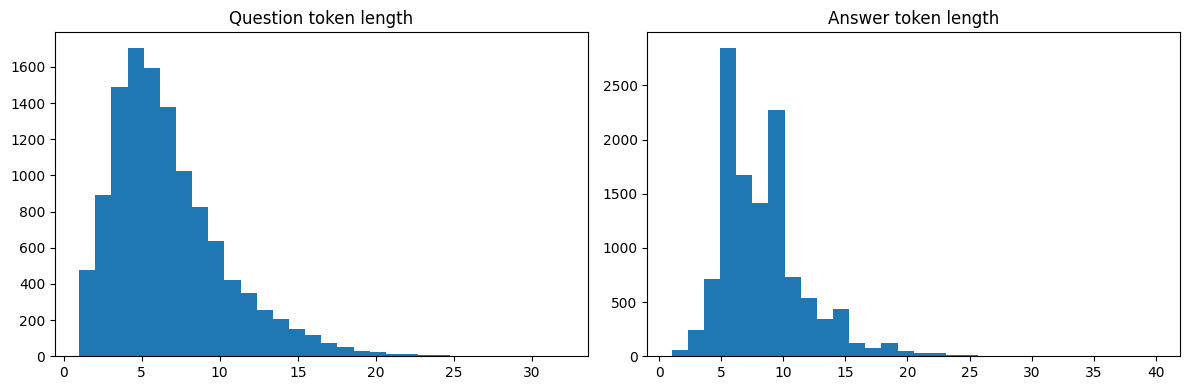

In [4]:
df["Q_tok"] = df["Q_clean"].apply(mecab.morphs)
df["A_tok"] = df["A_clean"].apply(mecab.morphs)

q_len = df["Q_tok"].apply(len)
a_len = df["A_tok"].apply(len)

print("Q 토큰 길이 통계:\n", q_len.describe())
print("\nA 토큰 길이 통계:\n", a_len.describe())
print("\nQ 백분위수 (90/95/97/99/100):", np.percentile(q_len, [90, 95, 97, 99, 100]))
print("A 백분위수 (90/95/97/99/100):", np.percentile(a_len, [90, 95, 97, 99, 100]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(q_len, bins=30)
axes[0].set_title("Question token length")
axes[1].hist(a_len, bins=30)
axes[1].set_title("Answer token length")
plt.tight_layout()
plt.show()

In [5]:
# A 토큰에는 학습 시 <start>/<end> 토큰이 추가되므로 +2를 고려해 MAX_LEN을 정합니다.
# 99번째 백분위수 부근에서 Q, A 모두 covering 되면서 지나치게 긴 이상치(꼬리)는 잘라내
# 패딩 낭비와 과적합 위험을 줄이는 지점을 선택합니다.
for candidate in [20, 22, 24, 25, 28, 30]:
    keep = (q_len <= candidate) & (a_len <= candidate - 2)
    print(f"MAX_LEN={candidate:>3}: 보존 {keep.sum():>6} ({keep.mean()*100:.2f}%)")

MAX_LEN = 24

keep_mask = (q_len <= MAX_LEN) & (a_len <= MAX_LEN - 2)
df = df[keep_mask].reset_index(drop=True)
print(f"\nMAX_LEN={MAX_LEN} 적용 후 데이터 크기: {df.shape}")

MAX_LEN= 20: 보존  11507 (97.93%)
MAX_LEN= 22: 보존  11623 (98.92%)
MAX_LEN= 24: 보존  11682 (99.42%)
MAX_LEN= 25: 보존  11694 (99.52%)
MAX_LEN= 28: 보존  11724 (99.78%)
MAX_LEN= 30: 보존  11730 (99.83%)

MAX_LEN=24 적용 후 데이터 크기: (11682, 7)


## Step 3. Train / Validation Split (Augmentation 이전)

Augmentation은 학습 데이터만 늘리기 위한 것이므로, **augmentation을 적용하기 전에** train/validation을 먼저 분리합니다.
그렇지 않으면 validation 문장의 augmentation 버전이 train에 섞여 들어가는 데이터 누수(leakage)가 발생합니다.

In [6]:
VAL_RATIO = 0.1

indices = np.arange(len(df))
rng = np.random.RandomState(SEED)
rng.shuffle(indices)
n_val = int(len(indices) * VAL_RATIO)
val_indices, train_indices = indices[:n_val], indices[n_val:]

train_df = df.iloc[train_indices].reset_index(drop=True)
val_df = df.iloc[val_indices].reset_index(drop=True)

print(f"train: {train_df.shape}, val: {val_df.shape}")

train: (10514, 7), val: (1168, 7)


## Step 4. Augmentation (Lexical Substitution)

사전 훈련된 한국어 Word2Vec 임베딩([Kyubyong/wordvectors](https://github.com/Kyubyong/wordvectors)의 Korean(w) 모델)을 이용해
`lexical_sub()`로 일부 형태소를 유사어로 치환합니다.

- `que_corpus`를 augmentation한 버전과 원본 `ans_corpus`를 병렬로 묶고 (그 반대도 동일하게) 학습 데이터를 원본의 약 3배로 늘립니다.
- Word2Vec 모델은 gensim 4.x와의 바이너리 포맷 호환성 문제로 사전에 `KeyedVectors.save_word2vec_format()` 포맷으로 변환해
  `work/data/ex08/wordvectors/ko_w2v.bin`에 저장해두었습니다.

In [7]:
from gensim.models import KeyedVectors

wv_model = KeyedVectors.load_word2vec_format(wv_path, binary=True)
print("word2vec vocab size:", len(wv_model.key_to_index))
print(wv_model.most_similar("강아지", topn=5))

_HANGUL_ONLY = re.compile(r"^[가-힣]+$")

def lexical_sub(tokens, sub_ratio=0.15, topn=5, rng=random):
    """형태소 리스트 중 일부를 word2vec 유사어로 치환. 치환이 없으면 None 반환."""
    candidate_idx = [
        i for i, t in enumerate(tokens)
        if _HANGUL_ONLY.match(t) and t in wv_model.key_to_index
    ]
    if not candidate_idx:
        return None

    n_sub = max(1, int(len(candidate_idx) * sub_ratio))
    sub_idx = rng.sample(candidate_idx, min(n_sub, len(candidate_idx)))

    new_tokens = tokens.copy()
    changed = False
    for i in sub_idx:
        similar_words = wv_model.most_similar(tokens[i], topn=topn)
        candidates = [w for w, _ in similar_words if w != tokens[i]]
        if candidates:
            new_tokens[i] = rng.choice(candidates)
            changed = True

    return new_tokens if changed else None

# 예시
sample_tokens = train_df["Q_tok"].iloc[0]
print("원본:", sample_tokens)
print("치환:", lexical_sub(sample_tokens))

word2vec vocab size: 30185
[('고양이', 0.7290452718734741), ('거위', 0.7185635566711426), ('토끼', 0.7056224346160889), ('멧돼지', 0.6950401067733765), ('엄마', 0.6934333443641663)]
원본: ['누가', '내', '욕', '하', '는', '거', '같', '아']
치환: ['누가', '내', '욕', '하', '는', '거', '똑같', '아']


In [8]:
que_corpus = train_df["Q_tok"].tolist()
ans_corpus = train_df["A_tok"].tolist()

aug_que_corpus = [lexical_sub(q) or q for q in que_corpus]
aug_ans_corpus = [lexical_sub(a) or a for a in ans_corpus]

# 원본 + (augmented Q, 원본 A) + (원본 Q, augmented A) => 원본의 약 3배
train_que_total = que_corpus + aug_que_corpus + que_corpus
train_ans_total = ans_corpus + ans_corpus + aug_ans_corpus

print(f"원본 학습 쌍: {len(que_corpus)}")
print(f"Augmentation 이후 학습 쌍: {len(train_que_total)} (약 {len(train_que_total)/len(que_corpus):.1f}배)")

원본 학습 쌍: 10514
Augmentation 이후 학습 쌍: 31542 (약 3.0배)


## Step 5. Vocab 구축 및 Tokenizer

Augmentation된 학습 데이터(train만, validation 제외)로부터 vocab을 만듭니다. 같은 언어(한국어-한국어) 챗봇이므로
질문/답변에 **동일한 vocab/tokenizer를 공유**합니다 (`shared_emb=True`와 자연스럽게 맞물림).

과적합 방지를 위해 `MIN_COUNT` 미만으로 등장한 희귀 형태소는 `<unk>`로 처리해 vocab 크기를 제한합니다.

기존에 정의된 `beam_search_decoder` / `translate` 등은 SentencePiece 스타일 인터페이스(`encode_as_ids`, `decode_ids`, `bos_id`, `eos_id`)를 사용하므로,
Mecab + vocab dict를 그 인터페이스에 맞춰 감싸는 `MecabTokenizer`를 정의합니다.

In [9]:
MIN_COUNT = 2
SPECIAL_TOKENS = ["<pad>", "<start>", "<end>", "<unk>"]

token_counter = Counter()
for tokens in train_que_total + train_ans_total:
    token_counter.update(tokens)

word2idx = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
for word, count in token_counter.items():
    if count >= MIN_COUNT and word not in word2idx:
        word2idx[word] = len(word2idx)
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE = len(word2idx)
print(f"전체 형태소 종류: {len(token_counter)}, MIN_COUNT={MIN_COUNT} 적용 후 VOCAB_SIZE: {VOCAB_SIZE}")


class MecabTokenizer:
    """SentencePiece 스타일 인터페이스(encode_as_ids/decode_ids/bos_id/eos_id)로 감싼 Mecab 토크나이저"""

    def __init__(self, mecab, word2idx, idx2word):
        self.mecab = mecab
        self.word2idx = word2idx
        self.idx2word = idx2word

    def pad_id(self):
        return self.word2idx["<pad>"]

    def bos_id(self):
        return self.word2idx["<start>"]

    def eos_id(self):
        return self.word2idx["<end>"]

    def unk_id(self):
        return self.word2idx["<unk>"]

    def vocab_size(self):
        return len(self.word2idx)

    def tokens_to_ids(self, tokens):
        return [self.word2idx.get(t, self.unk_id()) for t in tokens]

    def encode_as_ids(self, text):
        tokens = self.mecab.morphs(clean_text(text))
        return self.tokens_to_ids(tokens)

    def decode_ids(self, ids):
        specials = (self.pad_id(), self.bos_id(), self.eos_id())
        tokens = [self.idx2word.get(int(i), "<unk>") for i in ids if int(i) not in specials]
        return " ".join(tokens)


tokenizer = MecabTokenizer(mecab, word2idx, idx2word)
print(tokenizer.encode_as_ids("오늘 날씨가 참 좋네요"))
print(tokenizer.decode_ids(tokenizer.encode_as_ids("오늘 날씨가 참 좋네요")))

전체 형태소 종류: 8926, MIN_COUNT=2 적용 후 VOCAB_SIZE: 7710
[125, 414, 28, 363, 91, 3558]
오늘 날씨 가 참 좋 네요


## Step 6. 데이터셋 및 데이터로더 구현

인코더 입력은 `[Q 토큰 ... <pad>]`, 디코더 입력은 `[<start>, A 토큰 ...]`, 디코더 타깃은 `[A 토큰 ..., <end>]` 형태로 만들고
모두 `MAX_LEN` 길이로 패딩합니다. Validation은 augmentation 없이 원본 문장 그대로 인코딩합니다.

In [10]:
def encode_pair(q_tokens, a_tokens, max_len):
    q_ids = tokenizer.tokens_to_ids(q_tokens)[:max_len]
    a_ids = tokenizer.tokens_to_ids(a_tokens)[: max_len - 1]

    enc_in = q_ids + [tokenizer.pad_id()] * (max_len - len(q_ids))

    dec_in_ids = [tokenizer.bos_id()] + a_ids
    dec_in = dec_in_ids + [tokenizer.pad_id()] * (max_len - len(dec_in_ids))

    dec_tgt_ids = a_ids + [tokenizer.eos_id()]
    dec_tgt = dec_tgt_ids + [tokenizer.pad_id()] * (max_len - len(dec_tgt_ids))

    return enc_in, dec_in, dec_tgt


def build_arrays(que_list, ans_list, max_len):
    enc_ins, dec_ins, dec_tgts = [], [], []
    for q, a in zip(que_list, ans_list):
        e, di, dt = encode_pair(q, a, max_len)
        enc_ins.append(e)
        dec_ins.append(di)
        dec_tgts.append(dt)
    return (
        np.array(enc_ins, dtype=np.int64),
        np.array(dec_ins, dtype=np.int64),
        np.array(dec_tgts, dtype=np.int64),
    )


train_enc_in, train_dec_in, train_dec_tgt = build_arrays(train_que_total, train_ans_total, MAX_LEN)
val_enc_in, val_dec_in, val_dec_tgt = build_arrays(val_df["Q_tok"].tolist(), val_df["A_tok"].tolist(), MAX_LEN)

print("train arrays:", train_enc_in.shape, train_dec_in.shape, train_dec_tgt.shape)
print("val arrays:", val_enc_in.shape, val_dec_in.shape, val_dec_tgt.shape)


class ChatbotDataset(Dataset):
    def __init__(self, enc_in, dec_in, dec_tgt):
        self.enc_in = enc_in
        self.dec_in = dec_in
        self.dec_tgt = dec_tgt

    def __len__(self):
        return len(self.enc_in)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.enc_in[idx], dtype=torch.long),
            torch.tensor(self.dec_in[idx], dtype=torch.long),
            torch.tensor(self.dec_tgt[idx], dtype=torch.long),
        )


train_dataset = ChatbotDataset(train_enc_in, train_dec_in, train_dec_tgt)
val_dataset = ChatbotDataset(val_enc_in, val_dec_in, val_dec_tgt)

train arrays: (31542, 24) (31542, 24) (31542, 24)
val arrays: (1168, 24) (1168, 24) (1168, 24)


In [11]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"train batches: {len(train_loader)}, val batches: {len(val_loader)}")

sample_enc_in, sample_dec_in, sample_dec_tgt = next(iter(train_loader))
print(sample_enc_in.shape, sample_dec_in.shape, sample_dec_tgt.shape)

train batches: 492, val batches: 19
torch.Size([64, 24]) torch.Size([64, 24]) torch.Size([64, 24])


In [12]:
# 평가 함수
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)  # smoothing_function 적용

def calc_prob(src_ids, tgt_ids, model):
    # 마스크 생성 (PyTorch 버전)
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids,
        tgt_ids,
        enc_padding_mask,
        combined_mask,
        dec_padding_mask
    )

    # 마지막 차원에 대해 softmax 적용하여 확률값 계산
    return F.softmax(predictions, dim=-1)

def beam_search_decoder(sentence,
                        src_len,
                        tgt_len,
                        model,
                        src_tokenizer,
                        tgt_tokenizer,
                        beam_size):
    # 입력 문장을 토큰화
    tokens = src_tokenizer.encode_as_ids(sentence)

    # src_in: [1, src_len] 크기의 텐서로 padding (0: 패딩 토큰)
    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    # beam search용 캐시 배열들
    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp = np.zeros((beam_size, tgt_len), dtype=np.int64)

    eos_flag = np.zeros((beam_size,), dtype=np.int64)  # EOS를 만난 branch 표시 (EOS: -1)
    scores = np.ones((beam_size,), dtype=np.float32)     # 각 branch의 score (확률 곱)

    # 디코더 첫 입력은 BOS 토큰
    pred_tmp[:, 0] = tgt_tokenizer.bos_id()

    # 초기 디코더 입력 (branch 0의 첫 토큰) -> shape: [1, 1]
    dec_in = torch.tensor(pred_tmp[0, :1], dtype=torch.long, device=device).unsqueeze(0)
    # calc_prob()는 softmax를 적용한 확률 텐서를 반환함
    prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

    # seq_pos: 디코더 시퀀스 위치
    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size,), dtype=np.float32)

        # 각 beam branch에 대해 캐시 초기화
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            score_cache[cache_pos:cache_pos+beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos+beam_size, :seq_pos] = pred_tmp[branch_idx, :seq_pos]

        # 각 beam branch에 대해 후보 확률 계산 및 캐시 업데이트
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            if seq_pos != 1:
                # 해당 branch의 현재까지의 시퀀스를 디코더 입력으로 변환
                dec_in_np = pred_cache[branch_idx, :seq_pos]
                dec_in = torch.tensor(dec_in_np, dtype=torch.long, device=device).unsqueeze(0)
                prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

            # 각 branch 내에서 beam_size만큼의 후보 토큰을 선택
            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)
                # 후보 branch의 score 업데이트 (곱셈으로 누적)
                score_cache[cache_pos + beam_idx] *= prob[max_idx]
                pred_cache[cache_pos + beam_idx, seq_pos] = max_idx
                # 이미 선택된 토큰은 다시 선택되지 않도록 -1로 마킹
                prob[max_idx] = -1

        # 각 beam branch에서 최고 score를 가진 후보를 선택
        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1:
                continue
            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos+1].copy()
            pred_tmp[beam_idx, :seq_pos+1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1  # 해당 후보 제거

            # 만약 EOS 토큰이면 해당 branch는 종료 표시 (-1)
            if prediction[-1] == tgt_tokenizer.eos_id():
                eos_flag[beam_idx] = -1

    # 각 branch의 예측 시퀀스에서 EOS 토큰 이전까지만 추출하여 결과 반환
    pred = []
    for long_pred in pred_tmp:
        eos_token = tgt_tokenizer.eos_id()
        # EOS 토큰이 없는 경우, 전체 시퀀스를 사용하도록 처리할 수 있음
        try:
            eos_idx = list(long_pred).index(eos_token)
        except ValueError:
            eos_idx = tgt_len - 1
        short_pred = long_pred[:eos_idx+1]
        pred.append(short_pred.tolist())

    return pred

def beam_bleu(reference, ids, tokenizer):
    # 기준 문장을 토큰화
    reference_tokens = reference.split()

    total_score = 0.0
    num_candidates = len(ids)
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        # 후보 문장을 디코딩 후 토큰화
        candidate_sentence = tokenizer.decode_ids(candidate_ids)
        candidate_tokens = candidate_sentence.split()

        score = calculate_bleu(reference_tokens, candidate_tokens)

        print(f"Reference: {reference_tokens}")
        print(f"Candidate: {candidate_tokens}")
        print(f"BLEU: {score}")

        total_score += score

    return total_score / num_candidates

In [13]:
# Positional Encoding 
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


In [14]:
# 마스킹 함수
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask


In [15]:
# 모델 구현
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # Pre-LN 구조는 각 서브레이어 진입 전에만 LayerNorm을 적용하므로,
        # 잔차(residual) 스트림 자체는 정규화되지 않아 레이어를 거칠수록 값의 크기가
        # 커질 수 있습니다. 인코더/디코더 스택 출력을 최종적으로 한 번 더 정규화해
        # (Pre-LN Transformer의 표준 관행) fc 투영 이전 logit 크기를 안정시킵니다.
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        enc_out = self.final_norm(enc_out)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
        dec_out = self.final_norm(dec_out)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns
    
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns
    
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn
    
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

In [16]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(max(step, 1))
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

LABEL_SMOOTHING = 0.1

def loss_function(real, pred, label_smoothing=LABEL_SMOOTHING):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    label_smoothing: 과적합 방지를 위한 label smoothing 계수
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),
        real.contiguous().view(-1),
        reduction='none',
        label_smoothing=label_smoothing,
    )
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

In [17]:

# 번역(inference) 함수
def translate(tokens, model, src_tokenizer, tgt_tokenizer):
    # tokens: 입력 토큰 리스트
    # MAX_LEN: 최대 길이 (전역 변수 혹은 상수)
    # device: 모델과 데이터가 위치한 디바이스

    # tokens 길이가 MAX_LEN보다 크면 자르고, 작으면 0으로 패딩
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]
    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))

    # 배치 차원을 추가하여 텐서로 변환 (shape: [1, MAX_LEN])
    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=device)

    ids = []
    # 디코더의 첫 입력은 BOS 토큰 (배치 차원 추가)
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long, device=device)

    for i in range(MAX_LEN):
        # generate_masks는 padded_tokens와 현재 output으로부터 마스크들을 생성합니다.
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)

        # 모델 예측: predictions shape: [batch, seq_len, num_classes]
        predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)

        # 마지막 시퀀스 위치의 예측값을 소프트맥스 후 argmax로 선택
        predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()

        # EOS 토큰에 도달하면 현재까지의 예측 토큰 ids를 디코딩 후 반환
        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return result

        ids.append(predicted_id)
        # 현재 output에 새로운 예측 토큰을 연결 (dim=1)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    result = tgt_tokenizer.decode_ids(ids)
    return result

## Step 7. 하이퍼파라미터 및 모델 생성

작은 데이터셋(약 3만개 규모)에서의 과적합을 피하기 위해 다음을 함께 사용합니다.
- `dropout=0.3`, `label_smoothing=0.1`
- `shared_emb=True`, `shared_fc=True`로 임베딩/출력 투영 파라미터 공유(파라미터 수 절감)
- Noam(warmup) learning rate schedule + gradient clipping
- Early stopping + best model checkpoint 저장 (Step 8)

In [18]:
N_LAYERS = 2
D_MODEL = 512
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.3
POS_LEN = 200

WARMUP_STEPS = 1000
MAX_EPOCHS = 50
PATIENCE = 5
GRAD_CLIP_NORM = 1.0
WEIGHT_DECAY = 0.01

CKPT_DIR = os.path.join(base_path, "work", "data", "ex08", "ckpt")
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CKPT_DIR, "transformer_best.pt")

transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=POS_LEN,
    dropout=DROPOUT,
    shared_fc=True,
    shared_emb=True,
).to(device)

n_params = sum(p.numel() for p in transformer.parameters())
print(f"모델 파라미터 수: {n_params:,}")
print(f"학습 데이터 수: {len(train_dataset):,} / 검증 데이터 수: {len(val_dataset):,}")

lr_scheduler = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)
optimizer = torch.optim.AdamW(transformer.parameters(), betas=(0.9, 0.98), eps=1e-9, weight_decay=WEIGHT_DECAY)

모델 파라미터 수: 18,669,086
학습 데이터 수: 31,542 / 검증 데이터 수: 1,168


## Step 8. 학습 (Early Stopping + Best Model 저장)

In [19]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, path=BEST_MODEL_PATH):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss, model):
        improved = val_loss < self.best_loss - self.min_delta
        if improved:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return improved


def run_epoch(model, loader, optimizer=None, scheduler=None, global_step=0, desc=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n_batches = 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    iterator = tqdm(loader, desc=desc, leave=False) if desc else loader
    with context:
        for enc_in, dec_in, dec_tgt in iterator:
            enc_in = enc_in.to(device)
            dec_in = dec_in.to(device)
            dec_tgt = dec_tgt.to(device)

            enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_in, dec_in)
            preds, _, _, _ = model(enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask)
            loss = loss_function(dec_tgt, preds)

            if is_train:
                global_step += 1
                lr = scheduler(global_step)
                for g in optimizer.param_groups:
                    g["lr"] = lr
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1

    return total_loss / n_batches, global_step


history = {"train_loss": [], "val_loss": []}
early_stopping = EarlyStopping(patience=PATIENCE, path=BEST_MODEL_PATH)
global_step = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, global_step = run_epoch(
        transformer, train_loader, optimizer, lr_scheduler, global_step, desc=f"epoch {epoch} [train]"
    )
    val_loss, _ = run_epoch(transformer, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    improved = early_stopping.step(val_loss, transformer)
    marker = " (best, saved)" if improved else f" (no improvement {early_stopping.counter}/{PATIENCE})"
    current_lr = lr_scheduler(global_step)
    print(f"Epoch {epoch:>3}/{MAX_EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | lr {current_lr:.6f}{marker}")

    if early_stopping.should_stop:
        print(f"\nEarly stopping (patience={PATIENCE}) at epoch {epoch}. Best val_loss={early_stopping.best_loss:.4f}")
        break

epoch 1 [train]:   0%|          | 0/492 [00:00<?, ?it/s]

Epoch   1/50 | train_loss 105.1114 | val_loss 9.7890 | lr 0.000688 (best, saved)


epoch 2 [train]:   0%|          | 0/492 [00:00<?, ?it/s]

Epoch   2/50 | train_loss 10.7607 | val_loss 5.3192 | lr 0.001375 (best, saved)


epoch 3 [train]:   0%|          | 0/492 [00:00<?, ?it/s]

...

Epoch  27/50 | train_loss 2.9703 | val_loss 3.7805 | lr 0.000383 (no improvement 3/5)


epoch 28 [train]:   0%|          | 0/492 [00:00<?, ?it/s]

Epoch  28/50 | train_loss 2.9206 | val_loss 3.7801 | lr 0.000377 (no improvement 4/5)


epoch 29 [train]:   0%|          | 0/492 [00:00<?, ?it/s]

Epoch  29/50 | train_loss 2.8728 | val_loss 3.7974 | lr 0.000370 (no improvement 5/5)

Early stopping (patience=5) at epoch 29. Best val_loss=3.7724


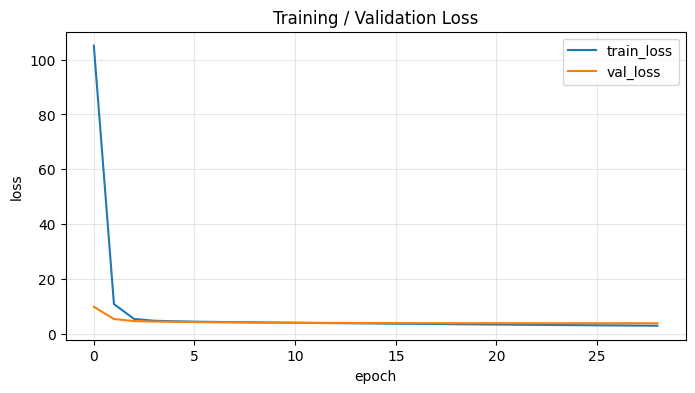

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 9. Best 모델 로드 및 BLEU 평가

Early stopping 과정에서 저장된 best model(가장 낮은 validation loss)을 불러와, validation 셋(augmentation이 적용되지 않은 원본 문장)에서
`translate()`로 문장을 생성하고 NLTK `sentence_bleu`로 평균 BLEU를 계산합니다.

In [21]:
transformer.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
transformer.eval()
print(f"Best model loaded from {BEST_MODEL_PATH} (val_loss={early_stopping.best_loss:.4f})")


def evaluate_bleu(model, q_texts, a_texts, n_samples=300, seed=42):
    rng_local = random.Random(seed)
    idxs = list(range(len(q_texts)))
    rng_local.shuffle(idxs)
    idxs = idxs[:n_samples]

    scores = []
    for i in idxs:
        q_ids = tokenizer.encode_as_ids(q_texts[i])
        candidate_text = translate(q_ids, model, tokenizer, tokenizer)
        candidate_tokens = candidate_text.split()
        reference_tokens = mecab.morphs(clean_text(a_texts[i]))

        if len(candidate_tokens) == 0:
            continue
        scores.append(calculate_bleu(reference_tokens, candidate_tokens))

    return sum(scores) / len(scores) if scores else 0.0


bleu_score = evaluate_bleu(transformer, val_df["Q_clean"].tolist(), val_df["A_clean"].tolist(), n_samples=300)
print(f"Validation BLEU (n=300 sample): {bleu_score:.4f}")

Best model loaded from /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/work/data/ex08/ckpt/transformer_best.pt (val_loss=3.7724)


Validation BLEU (n=300 sample): 0.0665


## Step 10. 챗봇 데모

In [22]:
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("Translations")
for i, sentence in enumerate(test_sentences, start=1):
    q_ids = tokenizer.encode_as_ids(sentence)
    response = translate(q_ids, transformer, tokenizer, tokenizer)
    print(f"> {i}. {response} <end>")

Translations
> 1. 제 가 들 어 드릴게요 . <end>
> 2. 잊 을 때 가 아니 에요 . <end>
> 3. 대화 를 나눠 보 세요 . <end>
> 4. 저 도 궁금 하 네요 . <end>


In [23]:
print("Hyperparameters")
print(f"> n_layers: {N_LAYERS}")
print(f"> d_model: {D_MODEL}")
print(f"> n_heads: {N_HEADS}")
print(f"> d_ff: {D_FF}")
print(f"> dropout: {DROPOUT}")
print()
print("Training Parameters")
print(f"> Warmup Steps: {WARMUP_STEPS}")
print(f"> Batch Size: {BATCH_SIZE}")
print(f"> Epoch At: {len(history['train_loss'])} (best val_loss={early_stopping.best_loss:.4f})")
print(f"> Validation BLEU: {bleu_score:.4f}")

Hyperparameters
> n_layers: 2
> d_model: 512
> n_heads: 8
> d_ff: 2048
> dropout: 0.3

Training Parameters
> Warmup Steps: 1000
> Batch Size: 64
> Epoch At: 29 (best val_loss=3.7724)
> Validation BLEU: 0.0665


## 데모 결과 평가

**생성된 응답**

| # | 입력 | 생성된 응답 |
|---|---|---|
| 1 | 지루하다, 놀러가고 싶어. | 제 가 들 어 드릴게요 . |
| 2 | 오늘 일찍 일어났더니 피곤하다. | 잊 을 때 가 아니 에요 . |
| 3 | 간만에 여자친구랑 데이트 하기로 했어. | 대화 를 나눠 보 세요 . |
| 4 | 집에 있는다는 소리야. | 저 도 궁금 하 네요 . |

**관찰 (참고용 — 정답 라벨이 없는 정성 평가라 확정적 결론은 아님)**

- 네 문장 모두 형태소 단위로는 자연스럽게 이어져 있고, 문법적으로 어색한 조합(조사 누락, 반복 토큰 등)은 보이지 않습니다. 학습이 완전히 붕괴하지는 않은 것으로 보입니다.
- 다만 입력 문장과의 의미적 연관성은 강하지 않아 보입니다. 예를 들어 3번("데이트 하기로 했어")에 대한 "대화를 나눠 보세요"는 그럴듯한 일반 조언이지만, 1번("놀러가고 싶어")에 대한 "제가 들어드릴게요"는 입력 의도와 다소 어긋나 보입니다.
- `ChatbotData.csv` 자체가 "~해 보세요", "~겠죠", "~네요"처럼 상황에 두루 쓰일 수 있는 범용 위로/조언형 응답 비중이 높은 데이터셋이라, 모델이 입력별로 세밀하게 구분하기보다 고빈도 응답 패턴 쪽으로 수렴했을 가능성을 의심해 볼 수 있습니다. (다만 이는 4개 샘플과 BLEU 지표만으로 확정하기는 어렵고, 더 많은 예시에 대한 정성 검토가 있으면 더 신뢰할 수 있는 판단이 될 것입니다.)
- Validation BLEU(0.0665)도 이 가설과 방향은 일치합니다 — 다만 챗봇 응답은 정답이 여러 개일 수 있는 open-ended task이므로, 낮은 BLEU 자체가 "나쁜 응답"을 의미하지는 않는다는 점은 감안해야 합니다. 사람이 보기에 그럴듯한 응답이어도 정답 문장과 표현이 다르면 BLEU는 낮게 나올 수 있습니다.
- 종합하면 문법적 유창성은 확보되었으나 입력에 대한 응답의 특이성(specificity)은 제한적인 것으로 보이며, 데이터 규모(3만개 남짓)와 모델 크기를 고려하면 어느 정도 예상되는 결과로 판단됩니다.